# Molecular dynamics analysis of HIV-1 protease

This Jupyter notebook presents a molecular dynamics analysis of the Human Immunodeficiency Virus type I (HIV-1) protease. We simulated HIV-1 protease (PDB ID: 1HVR) without its ligand for 201 ns. Then, a total of 201 frames were extracted at regular intervals of 1 ns from the molecular dynamics’ trajectory.

Here, we describe the conformational changes of a cavity that defines the active site of the HIV-1 protease, which is an effective therapeutic target. The HIV-1 protease catalytic cycle involves movements of β -hairpins, called 'flaps', which control the accessibility of substrates to the active site of the homodimer. Further, we performed a occurence of cavity points, that were detected in at least two frames, and we plotted all properties (volume, area, depth and hydropathy) throughout the simulation.

In [1]:
# Import required modules
import os
import pickle

import matplotlib.pyplot as plt
import numpy
import pyKVFinder
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

import KVFinderMD

## HIV-1 protease trajectory

## Cavity detection and characterization workflow


In [2]:
%%timeit -r 1 -n 1
# Create KVFinderMD object
md = KVFinderMD.KVFinderMD()

# Load HIV-1 protease trajectory
md.read_trajectory("data/HIV.pdb")

# Custom detection parameters
probe_out = 12.0
volume_cutoff = 50.0

# Perform detection and characterization
md.detect(
    # Analysis modes
    analyze_constitutional=True, 
    export_occurrence=True,
    analyze_spatial=True, 
    analyze_depth=True, 
    analyze_hydropathy=True,
    # Custom parameters
    probe_out=probe_out, 
    volume_cutoff=volume_cutoff,
    # Miscellaneous
    basedir='results/spde',
    verbose=True
)

# Write characterization to file
md.write('results/spde/results.toml')

# Save md with pickle
with open("results/spde/md.pkl", "wb") as f:
    pickle.dump(md, f)

[Frame:   0]  Elapsed time: 00s  Estimated time: 25s            

/home/ABTLUS/joao.guerra/remote-repos/jvsguerra/IV-CEC/.venv/lib/python3.10/site-packages/MDAnalysis/core/universe.py:743: UserWarning: Reader has no dt information, set to 1.0 ps
  dt=self.trajectory.ts.dt * step,



[Frame:   1]  Elapsed time: 02s  Estimated time: 04m04s            
[Frame:   2]  Elapsed time: 04s  Estimated time: 05m09s            
[Frame:   3]  Elapsed time: 06s  Estimated time: 05m43s            
[Frame:   4]  Elapsed time: 09s  Estimated time: 05m59s            
[Frame:   5]  Elapsed time: 11s  Estimated time: 06m12s            
[Frame:   6]  Elapsed time: 13s  Estimated time: 06m22s            
[Frame:   7]  Elapsed time: 16s  Estimated time: 06m27s            
[Frame:   8]  Elapsed time: 18s  Estimated time: 06m31s            
[Frame:   9]  Elapsed time: 20s  Estimated time: 06m34s            
[Frame:  10]  Elapsed time: 22s  Estimated time: 06m36s            
[Frame:  11]  Elapsed time: 25s  Estimated time: 06m38s            
[Frame:  12]  Elapsed time: 27s  Estimated time: 06m38s            
[Frame:  13]  Elapsed time: 29s  Estimated time: 06m39s            
[Frame:  14]  Elapsed time: 32s  Estimated time: 06m39s            
[Frame:  15]  Elapsed time: 34s  Estimated time

## Cavity alignment analysis

We explored three formulations for structural alignment of cavities:
- 3D grid alignment;
- (2D) Contact matrix alignment;
- (2D) Distance matrix alignment - Inspired on DALI structural alignment.


In [3]:
# Create directories
os.makedirs("results/spde/grid", exist_ok=True)
os.makedirs("results/spde/contact", exist_ok=True)
os.makedirs("results/spde/distance", exist_ok=True)

### 3D grid alignment: clustering 3D grid of each cavity detected throughout the molecular dynamics simulation

Here, we separate each cavity in a different boolean grid (1: cavity; 0: everything else).

In [4]:
if os.path.exists("results/spde/md.pkl"):
    with open("results/spde/md.pkl", "rb") as f:
        md = pickle.load(f)
    md.occurrence._gap = 1

In [5]:
# Separate each cavity in a different boolean grid
cavities = []
frames = []

for n in range(md.n_frames):
    f = md.frame(n)
    frames.append(n)
    
    for ncav in range(f.n_cavities):
        cavities.append(f.cavities == ncav+2)
        frames.append(f)

cavities = numpy.asarray(cavities)
frames = numpy.asarray(frames)

# Show grids
print(cavities.shape)

(672, 160, 126, 105)


In [6]:
# Prepare data
# NOTE: Memory consuming step
cavities = cavities.astype(bool).reshape(672, -1)

# Show data
print(cavities.shape)

(672, 2116800)


In [7]:
%%timeit -r 1 -n 1
preds = AgglomerativeClustering(n_clusters=10, metric='correlation', linkage="complete").fit_predict(cavities)

5min ± 21.2 s per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [8]:
preds = {}
preds["cavities"] = AgglomerativeClustering(n_clusters=10, metric='correlation', linkage="complete").fit_predict(cavities)

KVFinderMD.silhouette(
    cavities,
    preds['cavities'],
    metric='correlation',
    filename='results/spde/grid/silhouette.png'
)

# Write cavities to file
for i, cav in enumerate(cavities):
    cav = cav.reshape(160, 126, 105)
    B = numpy.ones(cav.shape) * preds["cavities"][i]
    pyKVFinder.export(
        f'results/spde/grid/{preds["cavities"][i]}/cavity-{i:03d}.pdb', 
        cav.astype(int) * 2, 
        None,
        md.kvtraj._vertices,
        md.kvtraj._step,
        B=B
    )

#### Similarity heatmap with dendrograms

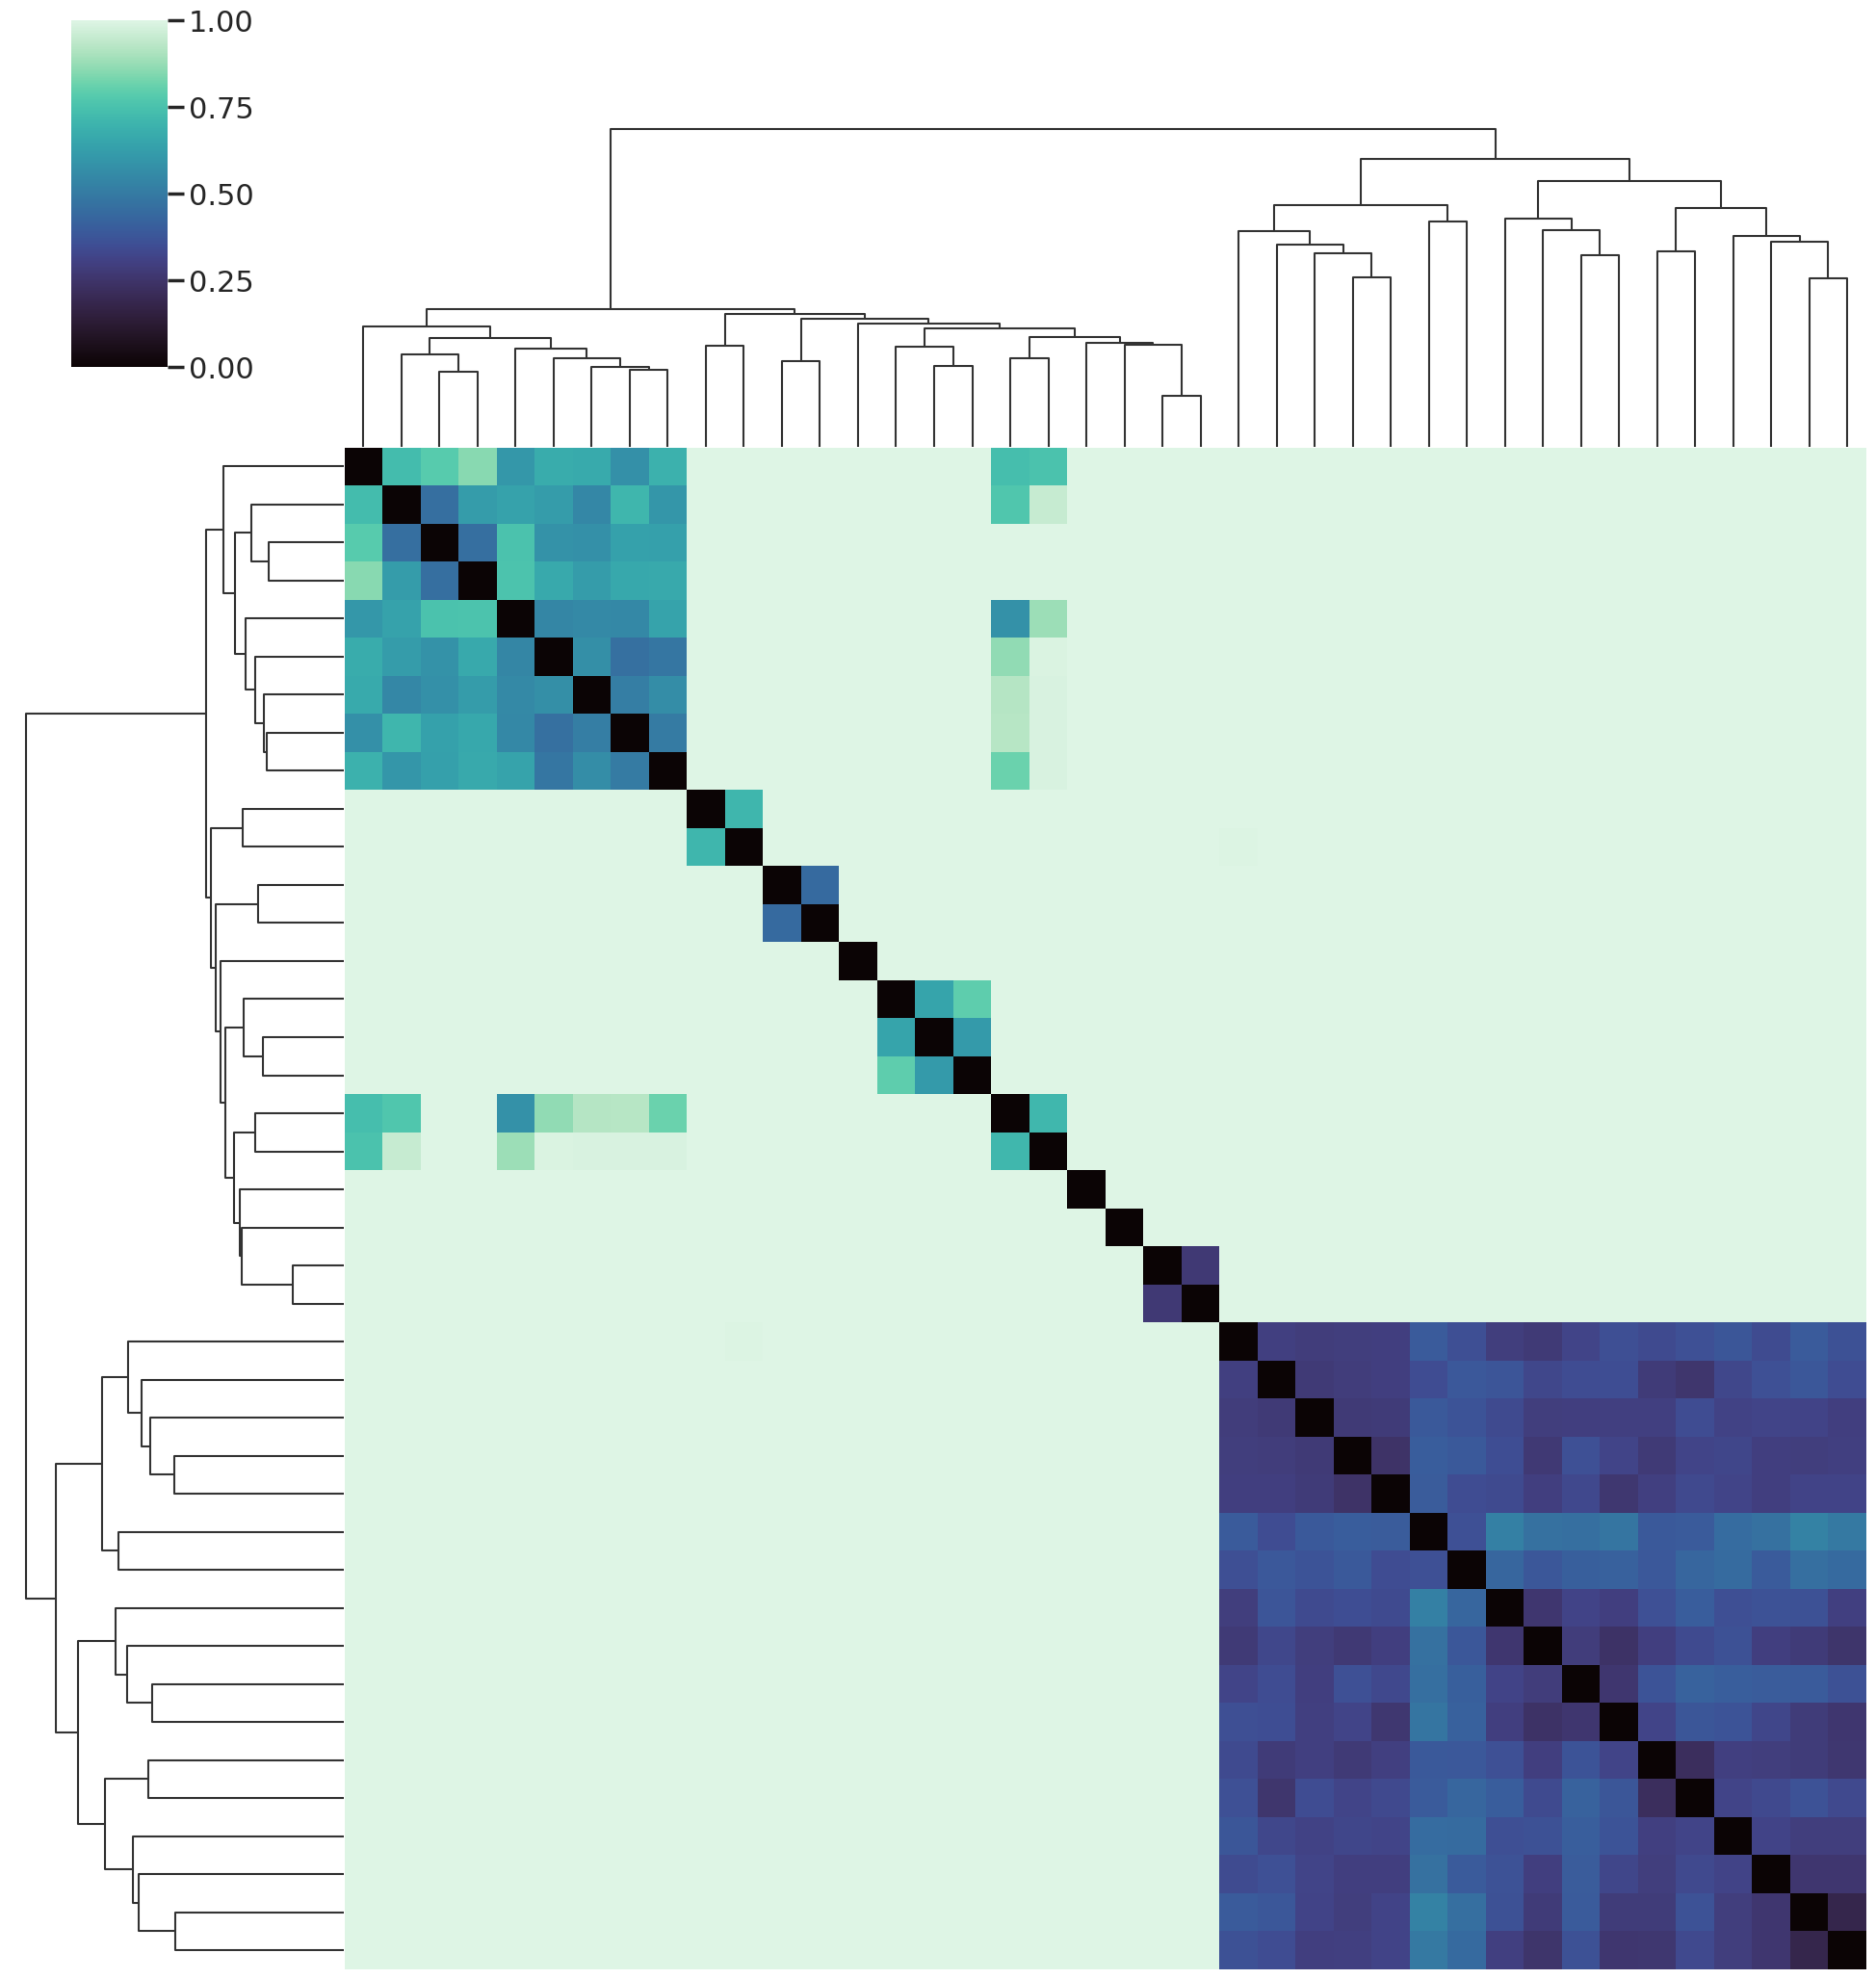

In [24]:
X = cavities[0:40]

D = squareform(pdist(X, metric="correlation"))

Z = linkage(pdist(X), method="complete")

sns.set_theme(context="poster", style="white")

g = sns.clustermap(
    D,
    row_linkage=Z,
    col_linkage=Z,
    cmap="mako",
    figsize=(20, 20),
    xticklabels=False,
    yticklabels=False,
    tree_kws={"linewidths": 1.5},
    dendrogram_ratio=(0.18, 0.18),
    cbar_pos=(0.05, 0.85, 0.05, 0.18),
)

# Colorbar
cbar = g.ax_heatmap.collections[0].colorbar
# cbar.set_ticks([0.01, 0.99])
 
# Transparent background
g.fig.patch.set_alpha(0)
 
plt.savefig(
    "results/spde/example-clustermap.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)

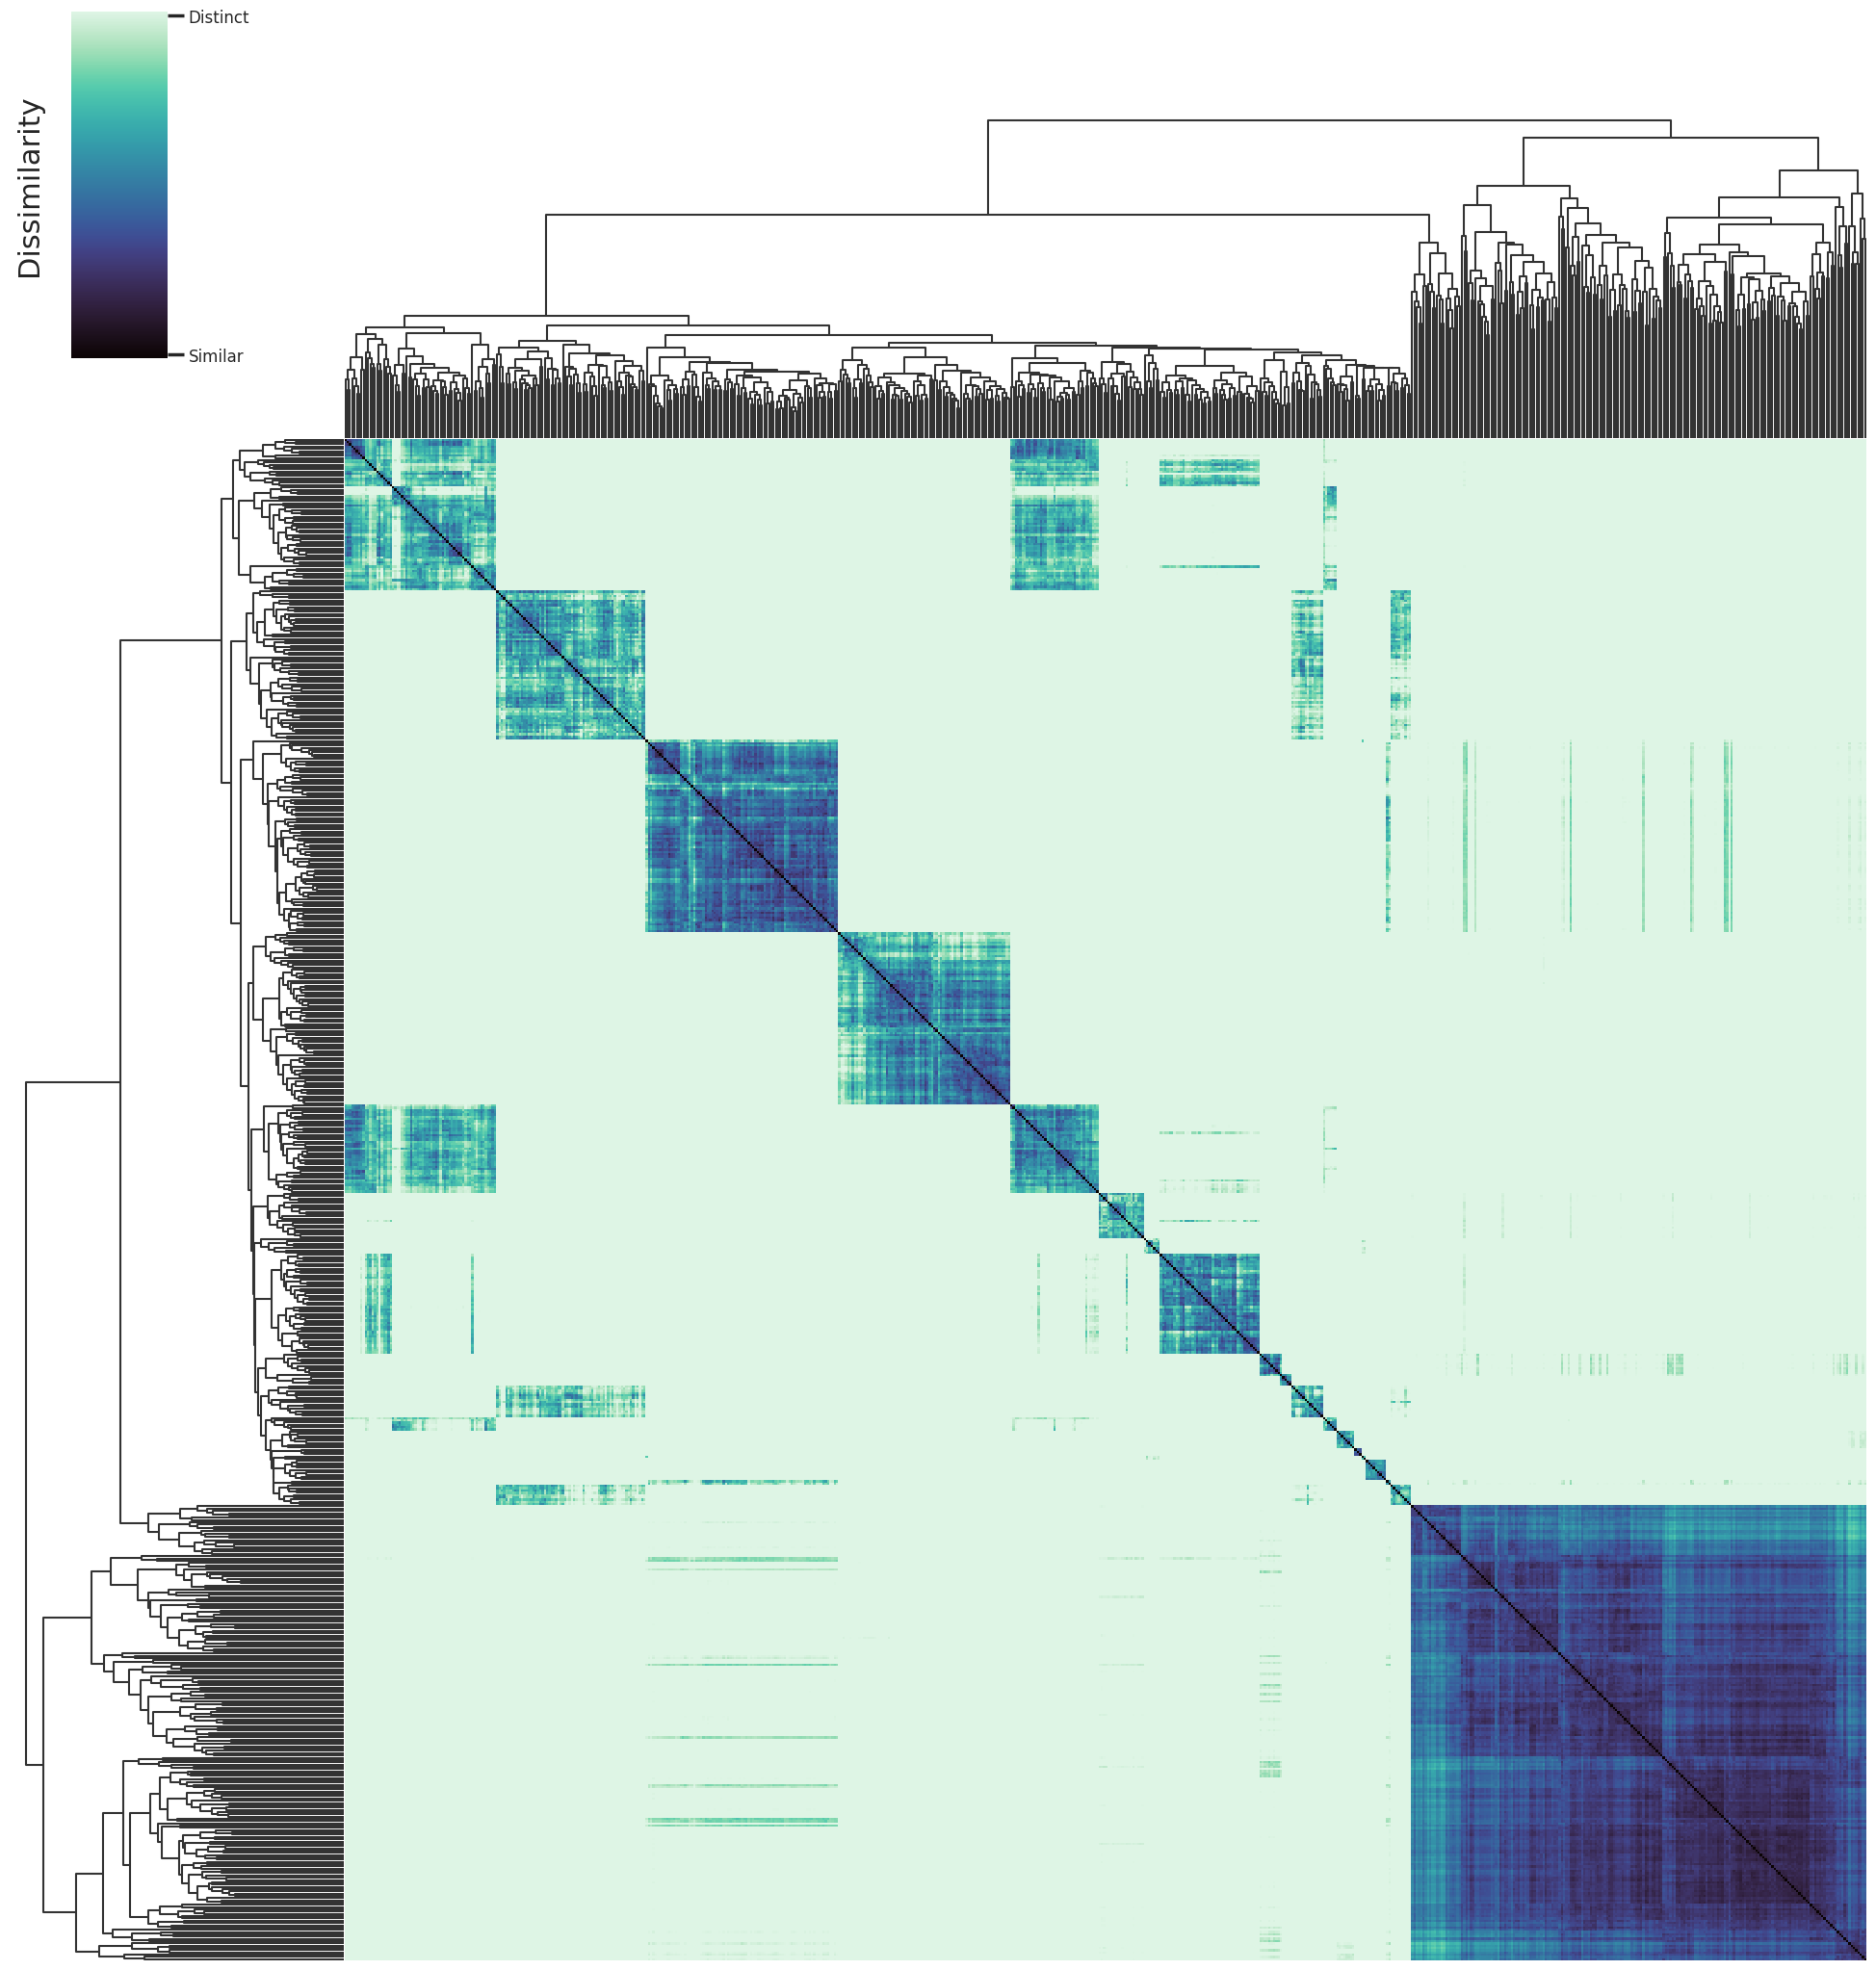

In [10]:
X = cavities

D = squareform(pdist(X, metric="correlation"))

Z = linkage(pdist(X), method="complete")

sns.set_theme(context="poster", style="white")

g = sns.clustermap(
    D,
    row_linkage=Z,
    col_linkage=Z,
    cmap="mako",
    figsize=(20, 20),
    xticklabels=False,
    yticklabels=False,
    tree_kws={"linewidths": 1.5},
    dendrogram_ratio=(0.18, 0.18),
    cbar_pos=(0.05, 0.85, 0.05, 0.18),
)

# Colorbar
cbar = g.ax_heatmap.collections[0].colorbar
cbar.set_ticks([0.01, 0.99])
cbar.set_ticklabels(["Similar", "Distinct"], size=12)
cbar.set_label(
    "Dissimilarity",
    fontsize=22,
    labelpad=-175,
)
 
# Transparent background
g.fig.patch.set_alpha(0)
 
plt.savefig(
    "results/spde/grid/clustermap.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)

#### Cavity clusters occupancy along trajectory

### (2D) Contact matrices alignment: clustering contact matrix of each cavity detected throughout the molecular dynamics simulation

Here, we define a contact matrix for each cavity, considering the interface residues surrounding it.

#### Explore distance metrics in 2D comparison of contact matrices

The distance metrics are used to assess the similarity of the adjacency matrices, ie the detected cavities.

The standard metrics: 
- Euclidean distance
- Correlation

Pairwise distances for booleans:
- Dice dissimilarity
- Hamming distance
- Jaccard dissimilarity
- Rogers-Tanimoto dissimilarity
- Russell-Rao dissimilarity
- Sokal-Michener dissimilarity
- Sokal-Sneath dissimilarity
- Yule dissimilarity

Discussion about those metrics:
- https://www.ibm.com/docs/en/spss-statistics/SaaS?topic=measures-distances-similarity-binary-data
- https://stats.stackexchange.com/questions/61705/similarity-coefficients-for-binary-data-why-choose-jaccard-over-russell-and-rao

In [11]:
# Create CavityAlignment object
alignment = KVFinderMD.CavityAlignment(md)

In [12]:
# Explore contact matrix alignment
alignment.explore(method="contact")

In [13]:
alignment.scores

,Number of Clusters,Silhouette Score
Correlation,11.0,0.557755
Dice,16.0,0.524279
Hamming,2.0,0.622585
Jaccard,16.0,0.401248
Rogers-Tanimoto,2.0,0.621012
Rusell-Rao,8.0,0.001496
Sokal-Michener,2.0,0.621012
Sokal-Sneath,16.0,0.279258
Yule,16.0,0.811657


In [14]:
%%timeit -r 1 -n 1
# Alignment
alignment.align(method='contact', affinity="dice")

4.86 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [15]:
alignment.align(method='contact', affinity="dice")
preds["contact"] = alignment.clusters

# Plot silhouette
KVFinderMD.silhouette(
    alignment.contacts.reshape(672, -1),
    alignment.clusters,
    metric='dice',
    filename='results/spde/contact/silhouette.png'
)

# Write cavities to file
for i, cav in enumerate(cavities):
    cav = cav.reshape(160, 126, 105)
    B = numpy.ones(cav.shape) * alignment.clusters[i]
    pyKVFinder.export(
        f'results/spde/contact/{alignment.clusters[i]}/cavity-{i:03d}.pdb', 
        cav.astype(int) * 2, 
        None, 
        md.kvtraj._vertices, 
        md.kvtraj._step,
        B=B
    )

/home/ABTLUS/joao.guerra/remote-repos/jvsguerra/IV-CEC/.venv/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric dice
  warnings.warn(msg, DataConversionWarning)
/home/ABTLUS/joao.guerra/remote-repos/jvsguerra/IV-CEC/.venv/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric dice
  warnings.warn(msg, DataConversionWarning)


#### Similarity heatmap with dendrograms

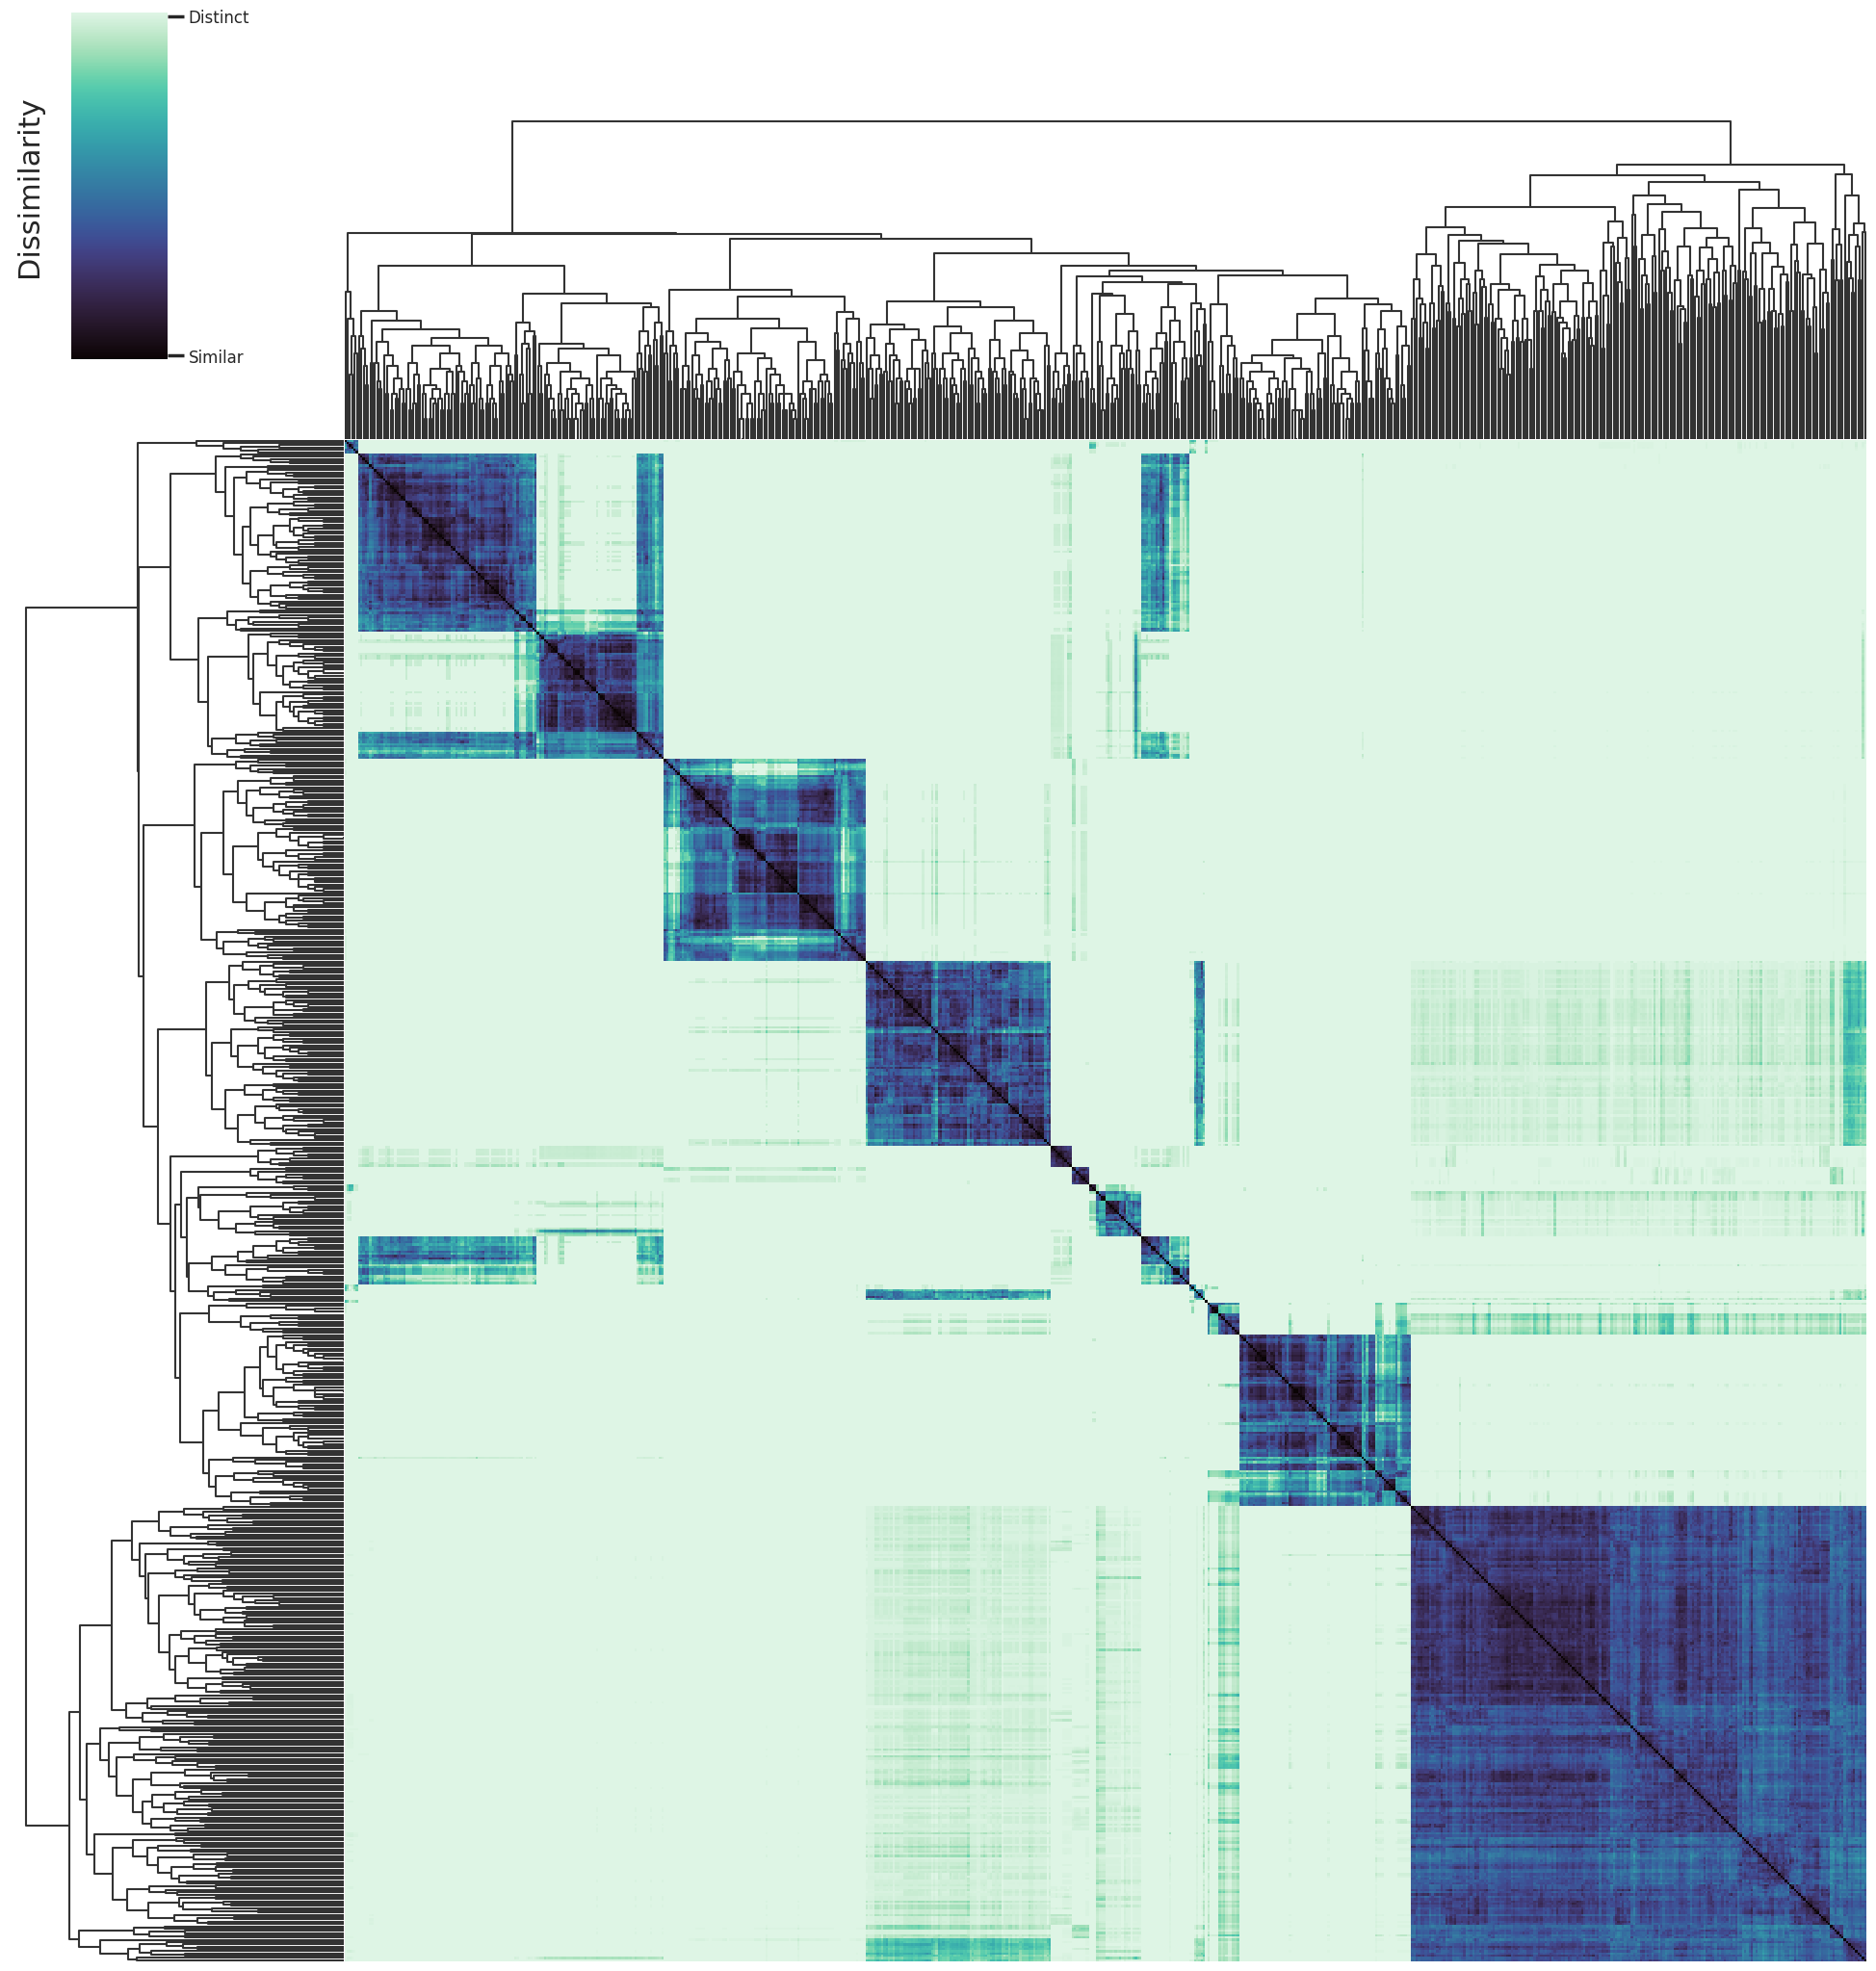

In [16]:
X = alignment.contacts.reshape(672, -1)

D = squareform(pdist(X, metric="dice"))

Z = linkage(pdist(X), method="complete")

sns.set_theme(context="poster", style="white")

g = sns.clustermap(
    D,
    row_linkage=Z,
    col_linkage=Z,
    cmap="mako",
    figsize=(20, 20),
    xticklabels=False,
    yticklabels=False,
    tree_kws={"linewidths": 1.5},
    dendrogram_ratio=(0.18, 0.18),
    cbar_pos=(0.05, 0.85, 0.05, 0.18),
)

# Colorbar
cbar = g.ax_heatmap.collections[0].colorbar
cbar.set_ticks([0.01, 0.99])
cbar.set_ticklabels(["Similar", "Distinct"], size=12)
cbar.set_label(
    "Dissimilarity",
    fontsize=22,
    labelpad=-175,
)
 
# Transparent background
g.fig.patch.set_alpha(0)
 
plt.savefig(
    "results/spde/contact/clustermap.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)

#### Cavity clusters occupancy along trajectory

### (2D) Distance matrices alignment: clustering contact matrix of each cavity detected throughout the molecular dynamics simulation

In [17]:
# Explore contact matrix alignment
alignment.explore(method="distance")

In [18]:
alignment.scores

,Number of Clusters,Silhouette Score
Euclidean,15.0,0.569840
Correlation,15.0,0.525135
Bray-Curtis,15.0,0.524059
Canberra,3.0,0.728975
Chebyshev,2.0,0.455468
City Block,8.0,0.714505
Cosine,15.0,0.528961
Jensen-Shannon,12.0,0.363735
Minkowski,15.0,0.569840
Squared Euclidean,15.0,0.723011


In [19]:
%%timeit -r 1 -n 1
# Alignment
alignment.align(method='distance', affinity="cosine")

4.46 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [20]:
alignment.align(method='distance', affinity="cosine")
preds["distance"] = alignment.clusters

# Plot silhouette
KVFinderMD.silhouette(
    alignment.distances.reshape(672, -1),
    alignment.clusters,
    metric="cosine",
    filename='results/spde/distance/silhouette.png'
)

# Write cavities to file
for i, cav in enumerate(cavities):
    cav = cav.reshape(160, 126, 105)
    B = numpy.ones(cav.shape) * alignment.clusters[i]
    pyKVFinder.export(
        f'results/spde/distance/{alignment.clusters[i]}/cavity-{i:03d}.pdb', 
        cav.astype(int) * 2, 
        None, 
        md.kvtraj._vertices, 
        md.kvtraj._step,
        B=B
    )

#### Similarity heatmap with dendrograms

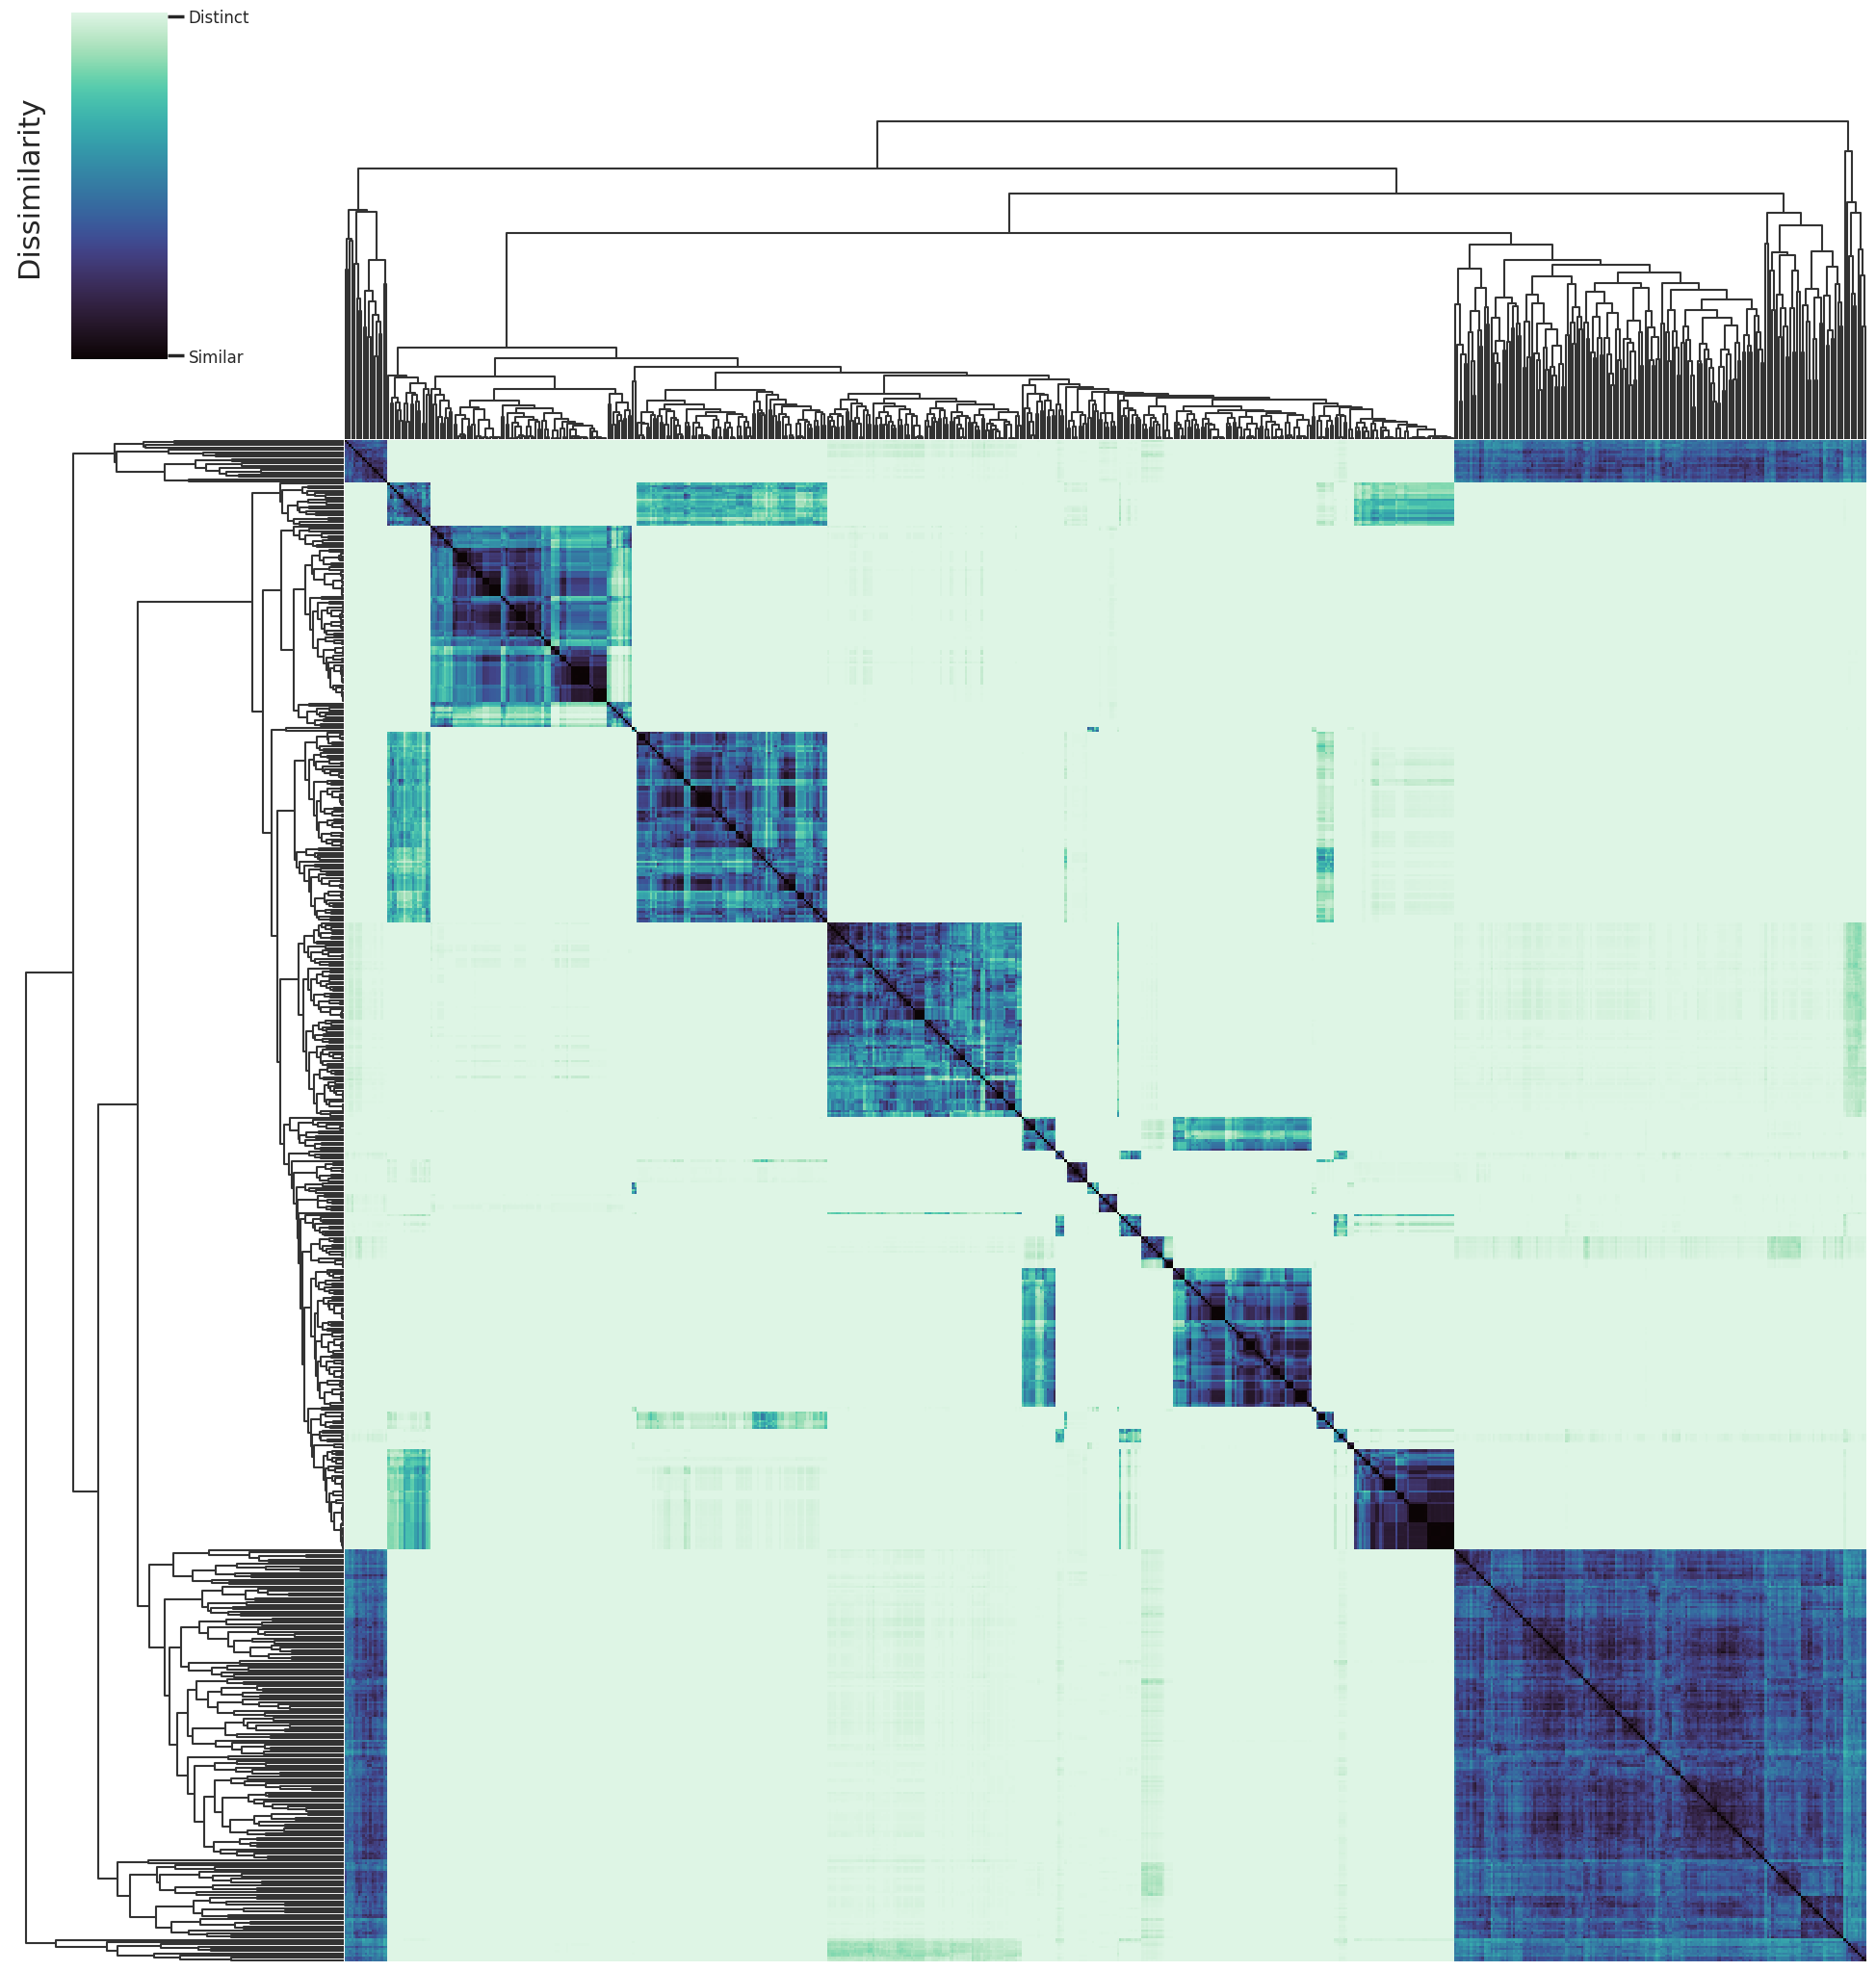

In [21]:
X = alignment.distances.reshape(672, -1)

D = squareform(pdist(X, metric="cosine"))

Z = linkage(pdist(X), method="complete")

sns.set_theme(context="poster", style="white")

g = sns.clustermap(
    D,
    row_linkage=Z,
    col_linkage=Z,
    cmap="mako",
    figsize=(20, 20),
    xticklabels=False,
    yticklabels=False,
    tree_kws={"linewidths": 1.5},
    dendrogram_ratio=(0.18, 0.18),
    cbar_pos=(0.05, 0.85, 0.05, 0.18),
)

# Colorbar
cbar = g.ax_heatmap.collections[0].colorbar
cbar.set_ticks([0.01, 0.99])
cbar.set_ticklabels(["Similar", "Distinct"], size=12)
cbar.set_label(
    "Dissimilarity",
    fontsize=22,
    labelpad=-175,
)
 
# Transparent background
g.fig.patch.set_alpha(0)
 
plt.savefig(
    "results/spde/distance/clustermap.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)

#### Cavity clusters occupancy along trajectory

### ARI and NMI scores for clustering comparison

In [45]:
# Cluster labels from each method
methods = {
    "3D Grid": preds["cavities"],
    "Residue-level\ndistances": preds["distance"],
    "Graph-based\ncontacts": preds["contact"],
}

names = list(methods.keys())
n = len(names)

ari = numpy.zeros((3, 3))
nmi = numpy.zeros((3, 3))

for i, name_i in enumerate(names):
    for j, name_j in enumerate(names):
        ari[i, j] = adjusted_rand_score(
            methods[name_i],
            methods[name_j],
        )
        nmi[i, j] = normalized_mutual_info_score(
            methods[name_i],
            methods[name_j],
        )

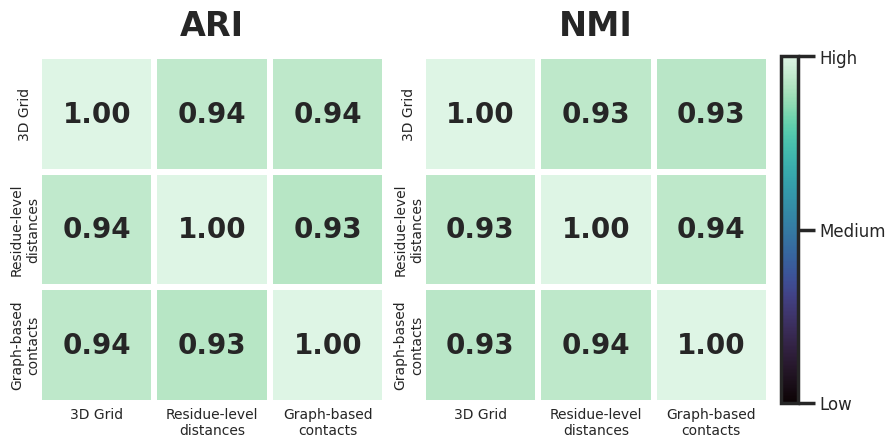

In [56]:
sns.set_theme(
    context="poster",
    style="white",
    font_scale=1.3,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4.5),
    gridspec_kw={"wspace": 0.10},
)

cmap = "mako"
vmin = 0
vmax = 1

sns.heatmap(
    ari,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    annot_kws={
        "fontsize": 20,
        "fontweight": "bold",
    },
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    linewidths=3,
    linecolor="white",
    xticklabels=names,
    yticklabels=names,
    cbar=False,
)

axes[0].set_title(
    "ARI",
    fontsize=24,
    fontweight="bold",
    pad=15,
)

sns.heatmap(
    nmi,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    annot_kws={
        "fontsize": 20,
        "fontweight": "bold",
    },
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    linewidths=3,
    linecolor="white",
    xticklabels=names,
    yticklabels=names,
    cbar=False,
)

axes[1].set_title(
    "NMI",
    fontsize=24,
    fontweight="bold",
    pad=15,
)

for ax in axes:

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(
        axis="x",
        rotation=0,
        labelsize=10,
        length=0,
    )

    ax.tick_params(
        axis="y",
        rotation=90,
        labelsize=10,
        length=0,
        pad=10
    )

for ax in axes:

    for label in ax.get_yticklabels():
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("center")
        label.set_multialignment("center")

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin, vmax),
)

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.04,
    pad=0.015,
)

cbar.set_ticks([0, 0.5, 1.0])

cbar.set_ticklabels([
    "Low",
    "Medium",
    "High",
])

cbar.ax.tick_params(
    labelsize=12,
)

fig.patch.set_alpha(0)

plt.savefig(
    "results/spde/method_agreement.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)

### Computational time

### Memory consumption